In [76]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=0)

# Vetorização e funções universais

Nos notebooks anteriores aprendemos a criar arrays e a acessar e extrair seus
elementos, mas até aqui fizemos muito pouco cálculo de verdade.  Este notebook
apresenta a justificativa por trás da existência do NumPy: aplicar a mesma
operação a milhões de números de uma só vez, de forma eficiente, e descrever
essa operação em uma única linha de código.

## $ \S 1 $ Motivação: o custo de um laço em Python

Suponha que queiramos calcular o recíproco de cada número dentro de um array.
Quem já tem alguma experiência com programação achará natural resolver esta
tarefa usando um laço:

In [ ]:
def compute_reciprocals(values):
    """ Calcula os recíprocos dos elementos de um array, um de cada vez. """
    output = np.empty(len(values))
    for i in range(len(values)):
        output[i] = 1.0 / values[i]
    return output


values = rng.integers(1, 10, size=5)
print(values)
print(compute_reciprocals(values))

[8 6 5 3 3]
[0.125      0.16666667 0.2        0.33333333 0.33333333]


O resultado está correto e, para cinco elementos, a execução é quase
instantânea. Vejamos agora o que acontece quando lhe damos um milhão de
elementos. Para medir o tempo gasto, usaremos o comando mágico do IPython
`%timeit`, que executa uma única instrução várias vezes e informa a duração
média de uma execução.

In [78]:
large_array = rng.integers(1, 100, size=1_000_000)

%timeit compute_reciprocals(large_array)

639 ms ± 4.14 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Dependendo do seu computador, o cálculo pode durar perto de $ 1 $ segundo, em média.
Ora, um milhão de divisões é uma quantidade trivial de trabalho para
processadores modernos. Até um celular realiza bilhões de operações de ponto
flutuante (flops) por segundo. No entanto, a maior parte do tempo consumido pelo
comando anterior foi gasta com tarefas de bastidores, e não com as divisões
propriamente ditas, como explicaremos agora.

Python é uma linguagem interpretada e de tipagem dinâmica. O nome `values[i]`
poderia se referir a um inteiro, a um float, a uma string ou a um objeto
definido pelo usuário, e o interpretador não tem como saber qual deles é até
inspecioná-lo em tempo de execução. Assim, a _cada passagem_ pelo laço, ele
precisa buscar o objeto, examinar seu tipo, localizar a rotina de divisão para
aquele tipo específico, chamá-la e, por fim, embrulhar a resposta em um objeto
Python novo em folha. Cada divisão em si leva apenas alguns nanossegundos, mas o
custo adicional associado pode levar cem vezes mais tempo.

<p align="center">
  <img src="loop_vs_ufunc.png" width="800">
  <br>
  <em>Figura 1: Para onde vai o tempo em um laço, e como o NumPy evita isto</em>
</p>

__Exercício:__ Reescreva `compute_reciprocals` como uma compreensão de lista
(_list comprehension_). Meça seu tempo com `%timeit` e compare. A compreensão é
mais rápida que o laço explícito? A diferença é grande o bastante para importar?

__Exercício:__ Escreva uma função `sum_of_squares(a)` que devolva
$ \sum_i a_i^2 $ usando um laço `for`, e meça seu tempo em um array de $ 10^6 $
floats aleatórios. Depois meça o tempo da expressão `np.sum(a**2)`, que calcula o
mesmo número. Por qual fator os dois diferem? 

In [ ]:
a = rng.random(1_000_000)


# def sum_of_squares(a):
#     ...

__Exercício:__ Como a diferença cresce com o tamanho da entrada? Complete o
código abaixo, que mede as duas abordagens para calcular as raízes quadradas
de todos os elementos de arrays de comprimento crescente, e
desenhe as duas curvas em escala log-log usando `ax.loglog`. _Dica:_
`time.perf_counter()` devolve o valor atual de um relógio de alta resolução em
segundos, de modo que a diferença entre duas leituras é um tempo decorrido. Faz
diferença usar `np.sqrt` ou `math.sqrt` dentro do laço?

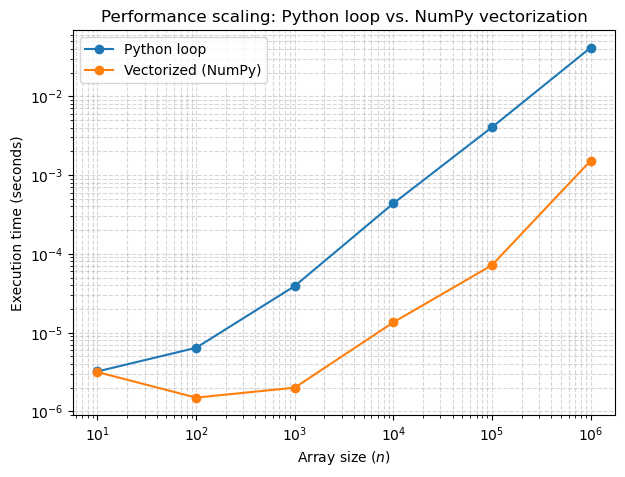

In [ ]:
from time import perf_counter
from math import sqrt

rng = np.random.default_rng()
sizes = 10 ** np.arange(1, 7)    # 10, 100, ..., 1_000_000
loop_times = []
vectorized_times = []

for n in sizes:
    a = rng.random(n)

    # 1. Abordagem com laço (preencha a compreensão de lista):
    start = perf_counter()
    list_of_square_roots = # ...
    loop_times.append(perf_counter() - start)

    # 2. Abordagem vetorizada (preencha o array)
    start = perf_counter()
    array_of_reciprocals = # ...
    vectorized_times.append(perf_counter() - start)

# Gráfico em escala log-log
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(sizes, loop_times, 'o-', label='Laço em Python')
ax.loglog(sizes, vectorized_times, 'o-', label='Vetorizado (NumPy)')

ax.set_xlabel('Tamanho do array ($ n $)')
ax.set_ylabel('Tempo de execução (segundos)')
ax.set_title('Escalabilidade: laço em Python vs. vetorização com NumPy')
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend()

plt.show()

## $ \S 2 $ Funções universais

Uma operação aplicada a um array inteiro de uma só vez, elemento a elemento, é
dita __vetorizada__. No NumPy, tais operações são realizadas por objetos
chamados __funções universais__, ou __ufuncs__, para abreviar. Uma ufunc sabe de
antemão que todos os elementos do array têm o mesmo tipo, de modo que pode
verificar este tipo uma única vez e depois executar um laço enxuto escrito em C
sobre um bloco contíguo de memória. Portanto, um laço continua existindo, só que
não em Python.

Com frequência, a vetorização faz o mesmo cálculo ser executado duas ou três
ordens de grandeza mais rápido do que um laço equivalente em Python.

As ufuncs vêm em dois sabores:
* As __unárias__ atuam sobre um único array. Exemplos são `np.sqrt`, `np.cos` e a negação `-x`.
* As __binárias__ atuam sobre dois arrays (ou sobre um array e um escalar). Exemplos são
  `np.add` ou a divisão que usamos acima.

<p align="center">
  <img src="elementwise.png" width="700">
  <br>
  <em>Figura 2: Uma ufunc binária atuando sobre dois arrays</em>
</p>

Os operandos não precisam ser unidimensionais, e uma ufunc nunca altera a forma
daquilo que recebe:

In [10]:
print(np.arange(5) / np.arange(1, 6), "\n")

x = np.arange(9).reshape((3, 3))
print(2 ** x)

[0.         0.5        0.66666667 0.75       0.8       ] 

[[  1   2   4]
 [  8  16  32]
 [ 64 128 256]]


⚠️ Por enquanto, quando uma ufunc recebe dois arrays, eles devem ter a mesma
forma. Na verdade o NumPy aceita certas formas incompatíveis e estica o operando
menor para ajustá-lo ao maior, um mecanismo chamado __broadcasting__ que
consideraremos mais adiante. Já usamos seu caso mais simples várias vezes: em
`1.0 / values`, o escalar $ 1.0 $ foi implicitamente esticado em um array de
cinco uns para corresponder ao comprimento de `values`.

__Exercício:__ Preveja o resultado de cada expressão abaixo e depois execute a
célula para conferir. Uma delas gera um erro: qual, e por quê?

In [ ]:
print(np.arange(4) + np.arange(4))
print(np.arange(4) + np.arange(1))
print(np.arange(4) + np.arange(5))

__Exercício:__ Cada um dos laços abaixo pode ser substituído por uma única
expressão. Reescreva-os e verifique que sua versão dá a mesma resposta. _Dicas:_
para (b), consulte `np.maximum`; para (c), lembre do notebook anterior que
`True` conta como $ 1 $ dentro de uma soma; para (d), o fatiamento é seu amigo (e
`np.diff` resolve isto em uma palavra).

In [ ]:
u = rng.random(1000)
v = rng.random(1000)

# (a)
result_a = np.empty(1000)
for i in range(1000):
    result_a[i] = u[i] * v[i] + 1

In [ ]:
# (b)
result_b = np.empty(1000)
for i in range(1000):
    if u[i] > v[i]:
        result_b[i] = u[i]
    else:
        result_b[i] = v[i]

In [ ]:
# (c)
count_c = 0
for i in range(1000):
    if u[i] > 0.5:
        count_c += 1

In [ ]:
# (d)
result_d = np.empty(999)
for i in range(999):
    result_d[i] = u[i + 1] - u[i]

__Exercício:__ A distância ao longo de uma esfera de raio $ R $ entre dois de
seus pontos de latitude e longitude $ (\varphi, \lambda) $ é dada por
$$
    d = R \arccos\big(\sin\varphi_1 \sin\varphi_2 +
        \cos\varphi_1 \cos\varphi_2 \cos(\lambda_1 - \lambda_2)\big)\,.
$$
Usando $ R = 6371\,\text{km} $, calcule em uma única expressão vetorizada a
distância de Porto Alegre a cada uma das outras cidades da tabela abaixo.
_Dica:_ `np.radians` converte graus em radianos. As ufuncs correspondentes
às funções seno e cosseno são `np.sin` e `np.cos`.

In [ ]:
names = np.array(["Porto Alegre", "São Paulo", "Manaus", "Lisboa", "Tóquio"])
latitudes = np.array([-30.03, -23.55, -3.10, 38.72, 35.68])
longitudes = np.array([-51.23, -46.63, -60.02, -9.14, 139.69])

## $ \S 3 $ Ufuncs aritméticas

Os operadores binários de adição, subtração, multiplicação, exponenciação,
resto e os dois tipos de divisão funcionam diretamente sobre arrays e,
quando usados com arrays, são de fato ufuncs:

In [84]:
x = np.arange(1, 11)

print("x      =", x)
print("x + 5  =", x + 10)
print("x - 5  =", x - 5)
print("x * 2  =", x * 2)
print("x**2   =", x**2)
print("-x     =", -x)
print("x / 2  =", x % 2)
print("x // 2 =", x // 2)

x      = [ 1  2  3  4  5  6  7  8  9 10]
x + 5  = [11 12 13 14 15 16 17 18 19 20]
x - 5  = [-4 -3 -2 -1  0  1  2  3  4  5]
x * 2  = [ 2  4  6  8 10 12 14 16 18 20]
x**2   = [  1   4   9  16  25  36  49  64  81 100]
-x     = [ -1  -2  -3  -4  -5  -6  -7  -8  -9 -10]
x / 2  = [1 0 1 0 1 0 1 0 1 0]
x // 2 = [0 1 1 2 2 3 3 4 4 5]


Eles podem ser combinados à vontade, e as regras usuais de precedência entre
eles continuam valendo.  Mais importante, cada um destes operadores é um apelido
de uma ufunc nomeada. Por exemplo, `+` na verdade chama `np.add`:

In [ ]:
print(x + 2)
print(np.add(x, 2))

| Operador | Ufunc equivalente | Descrição                                |
|:--------:|:------------------|:-----------------------------------------|
| `+`      | `np.add`          | Adição, por exemplo, $ 1 + 1 = 2 $        |
| `-`      | `np.subtract`     | Subtração, por exemplo, $ 3 - 2 = 1 $     |
| `-`      | `np.negative`     | Negação unária, por exemplo, $ -2 $       |
| `*`      | `np.multiply`     | Multiplicação, por exemplo, $ 2 \times 3 = 6 $ |
| `/`      | `np.divide`       | Divisão, por exemplo, $ 3 / 2 = 1.5 $     |
| `//`     | `np.floor_divide` | Divisão inteira, por exemplo, $ 3 // 2 = 1 $ |
| `**`     | `np.power`        | Exponenciação, por exemplo, $ 2^3 = 8 $   |
| `%`      | `np.mod`          | Resto, por exemplo, $ 9 \bmod 4 = 1 $     |

Conhecer os nomes destas funções é útil principalmente por duas razões: elas
aceitam argumentos extras que os operadores infixos não aceitam, e podem ser
passadas como argumentos para outras funções, já que em Python as funções são
objetos como quaisquer outros, ao contrário de operadores como `+`, que são
apenas palavras-chave ou tokens sintáticos da linguagem:

In [ ]:
print(type(np.add))

<class 'numpy.ufunc'>


In [ ]:
# Isto resultará em um erro, já que `+` não tem tipo em Python:
print(type(+))

__Exercício:__ Seja $ \boldsymbol{x} = (-7, -1, 0, 1, 7) $.

(a) Calcule `x // 2` e `x % 2`. Em C ou Java, `-7 / 2` trunca em direção a zero
e dá $ -3 $, e o resto é $ -1 $. O que o NumPy faz em vez disto, e a identidade
$ a = 2\,(a // 2) + (a \bmod 2) $ continua valendo?

(b) Calcule `x / 0`. Quais são os três tipos de valor que aparecem, e que aviso
é impresso? O cálculo é interrompido?

In [91]:
x = np.array([-7, -1, 0, 1, 7])

⚠️ __Exercício (uma armadilha clássica):__ Execute as duas células abaixo. A
primeira funciona e a segunda gera um erro. Explique a diferença. _Dica:_
pergunte a cada array o seu `dtype`, e lembre que `+=` modifica um array _in
place_, sem criar um novo.

In [11]:
a = np.arange(5)
a = a + 0.5
print(a, a.dtype)

[0.5 1.5 2.5 3.5 4.5] float64


In [12]:
b = np.arange(5)
b += 0.5
print(b, b.dtype)

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

⚡ __Exercício:__ Seja `z = np.arange(5)`. Quais das expressões a seguir são
legais, e o que produzem aquelas que são? Adivinhe primeiro, depois confira uma
a uma.
```python
z ** z        2 << z >> 2        z <- z        1j * z        z / 1 / 1        z < z > z
```
A terceira é uma armadilha para os olhos: não existe seta de atribuição em
Python. A última é uma armadilha de outro tipo, e a mensagem de erro que ela
produz merece ser lida com atenção. _(Adaptado dos_
[100 exercícios de NumPy](https://github.com/rougier/numpy-100) _de Rougier.)_

In [21]:
z = np.arange(5)

⚡ __Exercício:__ Mesma pergunta para as expressões abaixo. A última é
particularmente instrutiva.
```python
np.array(0) / np.array(0)
np.array(0) // np.array(0)
np.array([np.nan]).astype(int).astype(float)
```

__Exercício (esquema de Horner):__ Seja
$ p(t) = 3t^4 - 2t^3 + 7t - 5 $.

(a) Avalie $ p $ nos $ 1\,000 $ pontos do array `t = np.linspace(-2, 2,
1_000)` com uma única expressão, e desenhe o resultado com `ax.plot`.

(b) Agora escreva uma função `horner(coefficients, t)` que avalie um polinômio
arbitrário em cada ponto de um array `t`, usando o esquema de Horner
$$
    p(t) = \big(\!\cdots\big((c_n t + c_{n-1})\,t + c_{n-2}\big)t + \cdots\big)t + c_0\,.
$$
Sua função deve conter um laço `for` para iterar sobre os coeficientes (você
pode supor que eles estão armazenados no array de mesmo nome em ordem
decrescente de grau). Por que isto é perfeitamente aceitável, ao passo que um
laço sobre os pontos não seria?

## $ \S 4 $ Valores absolutos, sinais e arredondamento

O NumPy entende a função interna de valor absoluto do Python, e também
fornece sua própria ufunc `np.absolute`, mais conhecida pelo apelido `np.abs`:

In [ ]:
x = np.array([-2, -1, 0, 1, 2])

print(abs(x))
print(np.abs(x))

Para argumentos complexos esta ufunc devolve o módulo $ |a + bi| = \sqrt{a^2 +
b^2} $, que é o que se deve esperar:

In [ ]:
z = np.array([3 - 4j, 4 - 3j, 2 + 0j, 0 + 1j])

print(np.abs(z))

Estreitamente relacionadas estão `np.sign`, que devolve $ -1 $, $ 0 $ ou $ 1 $
conforme o sinal de cada elemento, e a família do arredondamento:

| Ufunc         | Efeito                                          |
|:--------------|:------------------------------------------------|
| `np.round`    | Arredonda para o inteiro mais próximo (empates vão para o par) |
| `np.floor`    | Arredonda para baixo, em direção a $ -\infty $  |
| `np.ceil`     | Arredonda para cima, em direção a $ +\infty $   |
| `np.trunc`    | Arredonda em direção a zero, descartando a parte fracionária |
| `np.copysign` | Copia o sinal do segundo argumento para o primeiro |

In [ ]:
y = np.array([-1.7, -0.5, 0.5, 1.5, 2.5, 2.7])

print("round:", np.round(y))
print("floor:", np.floor(y))
print("ceil: ", np.ceil(y))
print("trunc:", np.trunc(y))

📝 Olhe com atenção para a linha produzida por `np.round`: tanto $ 0.5 $ quanto
$ 2.5 $ foram arredondados para números pares, e $ 1.5 $ foi arredondado para
cima até $ 2 $. Isto é o __arredondamento da metade para o par__, a regra
adotada pelo [padrão IEEE 754](https://en.wikipedia.org/wiki/IEEE_754).
Arredondar sempre as metades para cima ou para baixo introduz um viés
sistemático em somas longas, o que pode levar a um acúmulo de erros de
arredondamento, enquanto arredondar para o valor par mais próximo não introduz
viés algum e os erros individuais em grande parte se cancelam.

__Exercício:__ Escreva uma expressão de uma linha que arredonde cada elemento de
um array _para longe de zero_, de modo que $ 1.2 \mapsto 2 $ e
$ -1.2 \mapsto -2 $. _Dica:_ combine `np.copysign`, `np.ceil` e `np.abs`.

In [29]:
y = rng.uniform(-10, 10, size=10)
print(y)

[-6.43324534  1.94021137 -0.64932771  5.31754123  3.33933275  7.31294648
  3.3582964  -6.23975902 -5.79918737 -4.49069363]


__Exercício:__ Dado um array de preços, calcule:

(a) Os preços arredondados ao centavo mais próximo.

(b) Os preços arredondados _para cima_ até o próximo múltiplo de $ 0.05 $, o
tipo de arredondamento que uma caixa registradora faz quando as moedas pequenas
saem de circulação. _Dica:_ pense no que $ 0.05 \cdot \lceil x / 0.05 \rceil $ faz.

In [ ]:
prices = np.array([3.141, 2.718, 1.414, 0.577, 2.645, 9.998])
print(prices)

[3.141 2.718 1.414 0.577 9.998]


## $ \S 5 $ Ufuncs de comparação, e `maximum` versus `max`

Os operadores de comparação `<`, `<=`, `>`, `>=`, `==` e `!=` também são ufuncs.
São binários e devolvem um array de booleanos com a mesma forma do (ou dos)
original(is), exatamente o tipo de máscara que usamos para filtrar no notebook
anterior:

In [ ]:
x = np.arange(6)

print(x > 3)
print(np.greater(x, 3))

⚠️ Há um par de nomes que os iniciantes confundem o tempo todo:
* `np.maximum(a, b)` é uma _ufunc binária_. Compara `a` e `b` posição por
  posição e devolve um array de mesma forma.
* `np.max(a)` é uma _agregação_. Percorre um único array e devolve um número,
  o maior elemento.

O mesmo vale para `np.minimum` e `np.min`.

In [ ]:
a = np.array([1, 5, 2, 8])
b = np.array([4, 3, 6, 7])

print(np.maximum(a, b))    # elemento a elemento
print(np.max(a))           # um único número

__Exercício:__ A função __ReLU__, onipresente em redes neurais, é definida
por $ \text{ReLU}(x) = \max(x, 0) $.

(a) Aplique-a a `x = np.linspace(-3, 3, 13)` usando `np.maximum`, e desenhe o
resultado.

(b) Obtenha os mesmos valores com `np.where`, que discutimos em um notebook
anterior. 

(c) Obtenha-os uma terceira vez multiplicando `x` por uma máscara booleana
adequada. Qual das três versões você acha mais legível?

__Exercício:__ Um _soft clipping_ (recorte suave) de um array mantém seus
valores dentro de um intervalo $ [\ell, u] $, substituindo tudo o que estiver
abaixo de $ \ell $ por $ \ell $ e tudo o que estiver acima de $ u $ por $ u $.

(a) Implemente isto com `np.maximum` e `np.minimum` para
$ \ell = -1 $ e $ u = 1 $.

(b) Faça de novo com a única chamada `np.clip(x, -1, 1)` e verifique que as duas
concordam por meio de `np.array_equal`.

In [43]:
x = np.round(rng.normal(0, 1.5, size=10), 2)
print(x)

[ 1.03 -0.74  0.78 -1.23 -0.57  0.24  1.72 -0.6  -1.39  2.16]


## $ \S 6 $ Funções trigonométricas

O NumPy também fornece ufuncs correspondentes às funções trigonométricas usuais
e às suas inversas.  Comecemos com um array de ângulos, _medidos em radianos_:

In [93]:
theta = np.linspace(0, np.pi, 3)

print("theta      =", theta)
print("sin(theta) =", np.sin(theta))
print("cos(theta) =", np.cos(theta))
print("tan(theta) =", np.tan(theta))

theta      = [0.         1.57079633 3.14159265]
sin(theta) = [0.0000000e+00 1.0000000e+00 1.2246468e-16]
cos(theta) = [ 1.000000e+00  6.123234e-17 -1.000000e+00]
tan(theta) = [ 0.00000000e+00  1.63312394e+16 -1.22464680e-16]


📝 Olhe para $ \sin \pi $ na saída: em vez de $ 0 $, obtivemos aproximadamente
$ 1.2 \times 10^{-16} $. Os valores são calculados dentro da precisão da
máquina, e o próprio $ \pi $ é armazenado apenas de forma aproximada, de modo
que quantidades que deveriam se anular podem sair como números muito pequenos em
vez de zeros. Este problema é intrínseco à finitude dos números de ponto
flutuante, e não um defeito do NumPy.

As funções inversas também estão disponíveis, sob os nomes `arcsin`, `arccos` e
`arctan`:

In [ ]:
x = np.array([-1, 0, 1])

print("arcsin(x) =", np.arcsin(x))
print("arccos(x) =", np.arccos(x))
print("arctan(x) =", np.arctan(x))

O NumPy suporta nativamente as três funções trigonométricas hiperbólicas
centrais $ \cosh $, $ \sinh $ e $ \tanh $, mas não fornece ufuncs diretas de
nível superior para a cotangente, a secante ou a cossecante (nem para suas
contrapartes hiperbólicas).

Como os ângulos são muitas vezes dados em graus, `np.radians` (também chamada de
`np.deg2rad`) e `np.degrees` são fornecidas para converter entre as duas
medidas:

In [ ]:
angles = np.array([0, 30, 45, 60, 90])

print(np.radians(angles))
print(np.round(np.sin(np.radians(angles)), 4))

__Exercício:__ No intervalo $ [-2\pi, 2\pi] $, amostrado em $ 500 $ pontos:

(a) Desenhe $ \sin x $ e $ \cos x $ nos mesmos eixos.

(b) Verifique a identidade $ \sin^2 x + \cos^2 x = 1 $. Comparar com `==` é uma
má ideia aqui; use `np.allclose` e explique por quê.

(c) Qual é o maior desvio de $ 1 $ que você observa? _Dica:_ combine
`np.abs` com `np.max`.

In [ ]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 500)

# fig, ax = plt.subplots(figsize=(8, 5))

__Exercício (batimentos):__ Quando dois tons puros de frequências próximas são
tocados juntos, o ouvido escuta um único tom cujo volume pulsa. A razão é a
identidade
$$
    \sin(2\pi f_1 t) + \sin(2\pi f_2 t) =
    2 \sin\!\Big(2\pi \frac{f_1 + f_2}{2}\,t\Big)
      \cos\!\Big(2\pi \frac{f_1 - f_2}{2}\,t\Big)\,.
$$
Tome $ f_1 = 440 $ e $ f_2 = 444 $ hertz e $ t $ percorrendo um segundo
amostrado em $ 8\,000 $ pontos. Desenhe a soma das duas ondas e, sobre ela, a
envoltória $ \pm 2\cos\big(2\pi \frac{f_1 - f_2}{2} t\big) $. Quantas pulsações
você conta por segundo?

__Exercício (figuras de Lissajous):__ Para $ t \in [0, 2\pi] $, a curva
paramétrica
$$
    x(t) = \sin(a t + \delta)\,, \qquad y(t) = \sin(b t)
$$
é chamada de figura de Lissajous. Desenhe-a para $ (a, b, \delta) = (3, 2, \pi/2) $,
e depois experimente outros valores. O que acontece quando $ a/b $ é irracional?
_Dica:_ use `ax.set_aspect("equal")` para que a curva não fique distorcida.

⚡ __Exercício:__ Dadas as coordenadas cartesianas de vários pontos, queremos
seu ângulo polar $ \theta \in (-\pi, \pi] $. A fórmula óbvia $ \theta =
\arctan(y/x) $ falha para pontos do segundo e do terceiro quadrantes, e explode
quando $ x = 0 $.

(a) Calcule `np.arctan(y / x)` para os pontos abaixo e identifique quais
respostas estão erradas.

(b) Calcule `np.arctan2(y, x)`, uma ufunc binária projetada para esta
finalidade, e verifique que agora todas as respostas estão corretas.

In [ ]:
xs = np.array([1, 0, -1, -1, 1])
ys = np.array([1, 1, 1, -1, -1])

## $ \S 7 $ Exponenciais e logaritmos

A família exponencial funciona como esperado:

In [ ]:
x = np.array([1, 2, 3])

print("e^x =", np.exp(x))
print("2^x =", np.exp2(x))
print("3^x =", np.power(3.0, x))

E a logarítmica também. A função `np.log` é o logaritmo natural;
para outras bases temos `np.log2` e `np.log10`. De modo mais geral, como o
NumPy atualmente não tem uma ufunc que lide com bases arbitrárias, para calcular
$ \log_b x $ precisamos recorrer à identidade
$$
\log_b x = \frac{\log(x)}{\log(b)}\,,
$$
onde o $ \log $ do lado direito denota o logaritmo em qualquer base.

In [98]:
x = np.array([1, 2, 4, 10])

print("ln(x)    =", np.log(x))
print("log2(x)  =", np.log2(x))
print("log10(x) =", np.log10(x))

ln(x)    = [0.         0.69314718 1.38629436 2.30258509]
log2(x)  = [0.         1.         2.         3.32192809]
log10(x) = [0.         0.30103    0.60205999 1.        ]


Há também duas ufuncs especializadas, `np.expm1` e `np.log1p`, que calculam
$ e^x - 1 $ e $ \ln(1 + x) $. Elas existem porque estas duas quantidades são
quase impossíveis de calcular com precisão pela via ingênua quando $ x $ é
minúsculo: neste caso, a soma $ 1 + x $ já pode perder alguns ou todos os
dígitos significativos de $ x $, antes mesmo de o logaritmo ser aplicado.

In [113]:
x = 1e-17

print("log(1 + x) =", np.log(1 + x))
print("log1p(x)   =", np.log1p(x))
print("exp(x) - 1 =", np.exp(x) - 1)
print("expm1(x)   =", np.expm1(x))

log(1 + x) = 0.0
log1p(x)   = 1e-17
exp(x) - 1 = 0.0
expm1(x)   = 1e-17


__Exercício:__ Para $ x $ percorrendo `np.logspace(-16, 0, 17)`, calcule o
erro relativo
$$
    \frac{\big|\ln(1 + x) - \texttt{log1p}(x)\big|}{\texttt{log1p}(x)}
$$
e desenhe-o contra $ x $ em escala log-log. Em torno de qual magnitude de $ x $
a fórmula ingênua começa a desmoronar?

__Exercício (datação por radiocarbono):__ A quantidade de carbono-14 restante
em uma amostra após $ t $ anos é $ N(t) = N_0\,2^{-t/T} $, onde $ T = 5730 $
anos é a meia-vida. Isolando $ t $,
$$
    t = -T \log_2\!\Big(\frac{N}{N_0}\Big)\,.
$$
O array abaixo contém a fração $ N/N_0 $ medida em cinco amostras.
Calcule a idade de cada uma, de forma vetorizada, e arredonde as respostas ao
ano mais próximo.

In [ ]:
fractions = np.array([0.95, 0.75, 0.50, 0.25, 0.03])

__Exercício (a função logística):__ A __sigmoide__
$$
    \sigma(x) = \frac{1}{1 + e^{-x}}
$$
leva toda a reta real no intervalo $ (0, 1) $ e é a função de ativação
tradicional das redes neurais.

(a) Implemente-a e desenhe-a em $ [-10, 10] $.

(b) Avalie sua implementação em `x = np.array([-1000.0, 1000.0])`. O que
acontece, e que aviso aparece?

(c) Para $ x < 0 $ a forma algebricamente equivalente $ \sigma(x) = e^{x}/(1 +
e^{x}) $ não transborda. Escreva uma versão que use `np.where` para escolher a
fórmula apropriada para cada elemento, e confirme que ela sobrevive ao teste de
(b). _Cuidado:_ `np.where` avalia _ambos_ os ramos antes de escolher, então você
também precisa impedir que o expoente transborde, por exemplo com `np.clip`.

⚡ __Exercício:__ Em estatística e em aprendizado de máquina muitas vezes é
preciso calcular $ \ln(e^{a} + e^{b}) $ onde $ a $ e $ b $ são números negativos
grandes, de modo que $ e^a $ e $ e^b $ sofrem underflow para zero e o logaritmo
devolve $ -\infty $. Compare a expressão ingênua com a ufunc `np.logaddexp(a, b)`
para `a = np.array([-800.0, -1.0])` e `b = np.array([-801.0, -2.0])`.

📝 Embora a lista de ufuncs do NumPy seja bem longa, ela cobre apenas as
funções de uso mais difundido. Para as mais exóticas, existe o submódulo
`scipy.special`, cujos membros também são ufuncs, e que contém quase toda função
especial que tem nome: Bessel, Legendre, integrais elípticas e assim por diante.

__Exercício (a regra 68-95-99.7):__ Se $ X $ segue uma distribuição normal
padrão, então
$$
    \Pr\big(|X| \le k\big) = \operatorname{erf}\!\Big(\frac{k}{\sqrt 2}\Big)\,.
$$
Calcule esta probabilidade para $ k = 1, 2, 3, 4, 5 $ em uma única expressão e
compare com a regra prática que diz que aproximadamente $ 68\% $, $ 95\% $ e
$ 99.7\% $ da massa está a até um, dois e três desvios padrão da média.

In [52]:
from scipy.special import erf

## $ \S 8 $ Três recursos importantes das ufuncs

### $ 8.1 $ Armazenar o resultado in-place em outro array

Toda ufunc aceita um argumento `out` que especifica onde o resultado deve ser armazenado:

In [ ]:
x = np.arange(5)
y = np.empty(5)

np.multiply(x, 10, out=y)
print(y)

Isto também funciona com views, de modo que podemos escrever o resultado de um
cálculo em uma a cada duas entradas de um array:

In [ ]:
y = np.zeros(10)

np.power(2, x, out=y[::2])
print(y)

Se tivéssemos escrito `y[::2] = 2**x`, o NumPy teria primeiro construído um
array temporário contendo $ 2^x $ e depois o copiado para `y`. Para cinco
elementos a diferença é irrelevante. Para um array de cem milhões de elementos,
este temporário é um gigabyte de memória que precisa ser alocado, escrito e
jogado fora, que é precisamente o custo adicional que o uso de `out` evita.

📝 As atribuições aumentadas `x += 1`, `x *= 2` e assim por diante são operações
in-place do mesmo tipo: modificam o array existente em vez de criar um novo.

__Exercício:__ Sejam `A` e `B` dois arrays de um milhão de floats aleatórios.
Calcule $ (A + B) \cdot \big(\!-\!A/2\big) $
de duas maneiras: primeiro com a expressão óbvia, depois usando apenas
argumentos `out` e operações in-place, de modo que nenhum array temporário seja
criado. Meça o tempo das duas com `%timeit`. _(Adaptado dos_
[100 exercícios de NumPy](https://github.com/rougier/numpy-100) _de Rougier.)_

In [ ]:
A = rng.random(1_000_000)
B = rng.random(1_000_000)
out = np.empty(1_000_000)
%timeit ...


2.93 ms ± 25 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### $ 8.2 $ Reduzir e acumular

Aplicar repetidamente uma ufunc binária aos elementos de um array até restar um
único valor chama-se __redução__. Toda ufunc binária tem um método
`reduce` que faz exatamente isto:

In [ ]:
x = np.arange(1, 6)

print(x)
print(np.add.reduce(x))         # 1 + 2 + 3 + 4 + 5
print(np.multiply.reduce(x))    # 1 * 2 * 3 * 4 * 5

Se, em vez do valor final, quisermos guardar cada resultado intermediário,
usamos `accumulate`:

In [ ]:
print(np.add.accumulate(x))
print(np.multiply.accumulate(x))

Para estes quatro casos particulares, o NumPy tem funções dedicadas, `np.sum`,
`np.prod`, `np.cumsum` e `np.cumprod`, e na prática usamos estas. Os métodos
`reduce` e `accumulate` existem porque funcionam com qualquer outra ufunc, para
a maioria das quais não há atalho.

__Exercício:__ Seja $ \boldsymbol x $ o array dado abaixo.

(a) O que `np.maximum.accumulate(x)` devolve? Descreva em palavras o que
significa a $ k $-ésima entrada da resposta.

(b) Calcule `np.minimum.reduce(x)`. Qual função conhecida isto reproduz?

(c) `np.logical_and.reduce(x > 0)` devolve um único booleano. Que pergunta ele
responde?

In [ ]:
x = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3])

__Exercício:__ A média acumulada de uma sequência $ x_1, \dots, x_n $ é a
sequência cujo $ k $-ésimo termo é $ (x_1 + \cdots + x_k)/k $. Calcule-a para um
array de $ 1\,000 $ números aleatórios sorteados uniformemente em $ [0, 1] $
usando `np.cumsum`, e desenhe-a. A lei dos grandes números diz que a curva deve
se assentar perto de $ 1/2 $; e isto acontece?

### $ 8.3 $ Produtos externos

O método `outer` aplica uma ufunc binária a _cada par_ formado por um elemento
do primeiro array e um elemento do segundo. De dois arrays de comprimentos
$ m $ e $ n $ obtemos um array $ m \times n $. A tabuada é uma linha de código:

In [ ]:
x = np.arange(1, 6)

print(np.multiply.outer(x, x))

<p align="center">
  <img src="outer.png" width="420">
  <br>
  <em>Figura 3: A tabuada como um produto externo</em>
</p>

__Exercício:__ Construa os arrays a seguir com uma única chamada a algum método
`outer`.

(a) A tabela de adição $ 10 \times 10 $.

(b) A matriz de distâncias $ d_{ij} = |x_i - x_j| $ entre os pontos de
`x = np.array([0, 1, 4, 9, 16])`. Verifique que a diagonal é nula e que a
matriz é simétrica.

(c) A __matriz de Cauchy__ $ c_{ij} = \dfrac{1}{x_i - y_j} $ para
`x = np.arange(8)` e `y = np.arange(8) + 0.5`.

⚡ __Exercício:__ Use `np.less_equal.outer` para construir um array
$ 5 \times 5 $ cuja entrada $ (i, j) $ é `True` exatamente quando $ i \le j $,
ou seja, uma máscara triangular superior. Depois compare seu resultado com
`np.triu(np.ones((5, 5), dtype=bool))`.

## $ \S 9 $ Pensando em arrays

Vetorizar é mais do que uma questão de velocidade. A mudança mais profunda está
em como um problema passa a ser descrito: em vez de explicar ao computador o que
fazer com o elemento de número $ i $, precisamos pensar em como operar sobre a
coleção inteira de uma só vez. Os exercícios desta seção são pequenas simulações
que ficam mais naturais quando escritas neste segundo estilo.

__Exercício (passeio aleatório):__ Um caminhante parte da origem e, a cada
passo, move-se uma unidade para a esquerda ou para a direita com igual
probabilidade.

(a) Simule $ 1\,000 $ passos e desenhe a trajetória. _Dica:_ produza um array de
passos $ \pm 1 $ com `rng.choice([-1, 1], size=1000)`, depois use `np.cumsum`.

(b) Em que passo o caminhante alcança pela primeira vez uma distância de $ 10 $
da origem? _Dica:_ construa a máscara `np.abs(position) >= 10` e use `np.argmax`
sobre ela, lembrando que `argmax` em um array booleano encontra o primeiro
`True`.

(c) Agora simule $ 5\,000 $ caminhantes independentes de $ 1\,000 $ passos cada,
como um array de forma $ (5\,000, 1\,000) $, usando `axis=1` na soma cumulativa.
Calcule a distância quadrática média à origem em cada passo, e desenhe-a contra
o número do passo. Compare com a curva $ y = t $. Esta é a lei da difusão: um
caminhante aleatório se afasta da origem como $ \sqrt{t} $, e não como $ t $.

__Exercício (Monte Carlo, revisitado):__ Em um notebook anterior estimamos
$ \pi $ atirando dardos em um quadrado e contando quantos caíam dentro do disco
inscrito, um dardo de cada vez. Reescreva aquela estimativa sem laço algum:

(a) Sorteie $ N = 10^6 $ pontos uniformemente em $ [-1, 1]^2 $ como dois arrays
`x` e `y`.

(b) Construa a máscara booleana dos pontos que satisfazem $ x^2 + y^2 \le 1 $ e
conte-os com `np.sum`.

(c) Informe a estimativa $ 4n/N $ e compare com `np.pi`. Meça o tempo da sua
versão contra uma baseada em laço: quanto ganhamos?

(d) Desenhe a estimativa em função do número de dardos lançados, para a mesma
amostra. _Dica:_ `np.cumsum` da máscara dividido por `np.arange(1, N + 1)`.

__Exercício (integração numérica):__ A regra do trapézio aproxima
$ \int_a^b f(x)\,dx $ por
$$
    h\left(\frac{f(x_0)}{2} + f(x_1) + \cdots + f(x_{n-1}) +
    \frac{f(x_n)}{2}\right)\,, \qquad h = \frac{b - a}{n}\,.
$$

(a) Implemente-a de forma vetorizada e teste-a em $ \int_0^\pi \sin x\,dx = 2 $.

(b) Desenhe o erro absoluto contra $ n $, para $ n $ de $ 10 $ até $ 10^5 $, em
escala log-log. A inclinação da reta informa a ordem do método: qual é ela?

(c) Compare seus resultados com `np.trapezoid` (chamada `np.trapz` no NumPy 1.x).

⚡ __Exercício (o conjunto de Mandelbrot):__ Para um número complexo $ c $,
considere a sequência $ z_0 = 0 $, $ z_{n+1} = z_n^2 + c $. O conjunto de
Mandelbrot é o conjunto dos $ c $ para os quais a sequência permanece limitada,
e sabe-se que a sequência escapa para o infinito assim que $ |z_n| > 2 $.

Complete o código abaixo, que itera a recorrência sobre uma grade inteira de
números complexos _ao mesmo tempo_, e exiba o resultado com `ax.imshow`. O
único laço é sobre a contagem de iterações; não há laço sobre os pixels.
_Dica:_ `np.meshgrid` constrói a grade de coordenadas.

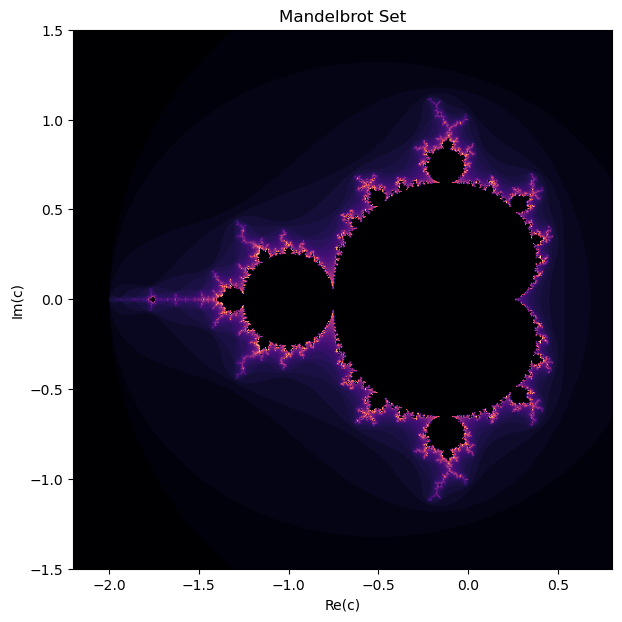

In [ ]:
n = 600
x = np.linspace(-2.2, 0.8, n)
y = np.linspace(-1.5, 1.5, n)
xx, yy = np.meshgrid(x, y)
c = xx + 1j * yy

z = np.zeros_like(c)
escape_time = np.zeros(c.shape, dtype=int)

for k in range(50):
    still_bounded = np.abs(z) <= 2
    # Atualize apenas os pontos que ainda não escaparam e registre
    # a iteração em que cada um dos demais escapou:
    # ...

# fig, ax = plt.subplots(figsize=(7, 7))
# ax.imshow(escape_time, extent=[-2.2, 0.8, -1.5, 1.5], cmap="magma")